Profiles `chunks.json` **after chunking**, to confirm the chunker produced a healthy index before embedding.

Produces:
- token / char / word length distributions per chunk (headline: token histogram)
- size flags (chunks below a useful size, chunks exceeding model context)
- integrity checks (empty chunks, duplicate ids, duplicate content, noise)
- structure (level + per-chapter distribution, chunks per section)
- conservation (sections silently dropped by the chunker)

## 0. Setup

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# bge-m3 native context is 8192 tokens

# Chunk profiling config
TARGET_CHUNK_SIZE = 500      # tokens per chunk used when building
MIN_USEFUL_TOKENS = 100      # chunks below this are low-information
NEAR_EMPTY_CHARS  = 30       # chunks shorter than this are suspect
MODEL_CTX         = 8192     # bge-m3 max context
EMBEDDING_MODEL   = "BAAI/bge-m3"

In [3]:
CHUNKS_PATH   = Path("../../data/processed/chunks.json")
SECTIONS_PATH = Path("../../data/processed/cleaned_sections.json")

## 1. Load into a DataFrame

In [5]:
with open(CHUNKS_PATH, encoding="utf-8") as f:
    chunks = json.load(f)

with open(SECTIONS_PATH, encoding="utf-8") as f:
    sections = json.load(f)

df = pd.DataFrame(chunks)

print(f"{len(df)} chunks from {len(sections)} sections")
df.head()

119 chunks from 63 sections


,chunk_id,text,raw_text,token_count,number,title,chapter_title,section_number,section_title,page_start,page_end,level
0,1__000,INTRODUÇÃO > INTRODUÇÃO\n\nNeste capítulo será...,Neste capítulo será realizado o enquadramento ...,62,1,INTRODUÇÃO,INTRODUÇÃO,NaN,NaN,20,20,chapter
1,1.1__000,INTRODUÇÃO > Enquadramento\n\nAs empresas do s...,As empresas do setor de retalho alimentar ofer...,474,1.1,Enquadramento,INTRODUÇÃO,NaN,NaN,20,21,section
2,1.1__001,INTRODUÇÃO > Enquadramento\n\n. Quando lidamos...,". Quando lidamos com a eficiência do armazém, ...",221,1.1,Enquadramento,INTRODUÇÃO,NaN,NaN,20,21,section
3,1.2__000,INTRODUÇÃO > Objetivos\n\nOs principais objeti...,Os principais objetivos deste projeto passam p...,269,1.2,Objetivos,INTRODUÇÃO,NaN,NaN,21,21,section
4,1.3__000,INTRODUÇÃO > Metodologia de Investigação\n\nCo...,Com vista a atingir todos os trabalhos propost...,404,1.3,Metodologia de Investigação,INTRODUÇÃO,NaN,NaN,21,23,section


## 2. Length columns

In [6]:
# token_count already comes from chunking.py; add char / word for parity
df["char_count"] = df["raw_text"].str.len()
df["word_count"] = df["raw_text"].str.split().map(len)

print("tokenizer:", EMBEDDING_MODEL)
df[["chunk_id","title","level","token_count","char_count","word_count"]].head()

tokenizer: BAAI/bge-m3


,chunk_id,title,level,token_count,char_count,word_count
0,1__000,INTRODUÇÃO,chapter,62,291,43
1,1.1__000,Enquadramento,section,474,2010,313
2,1.1__001,Enquadramento,section,221,998,152
3,1.2__000,Objetivos,section,269,1240,186
4,1.3__000,Metodologia de Investigação,section,404,1870,279


## 3. Summary statistics

In [7]:
stats = df[["token_count","word_count","char_count"]].describe(
    percentiles=[.5,.75,.95]).round(1)
print(stats)

print("\nBy level (token_count):")
print(df.groupby("level")["token_count"].describe()[["count","mean","min","max"]].round(1))

       token_count  word_count  char_count
count        119.0       119.0       119.0
mean         379.8       246.0      1582.3
std          133.4        92.7       581.5
min           62.0        43.0       291.0
50%          457.0       286.0      1834.0
75%          491.0       322.0      2066.0
95%          515.0       347.0      2232.0
max          524.0       356.0      2379.0

By level (token_count):
            count   mean    min    max
level                                 
chapter      12.0  295.8   62.0  524.0
section      47.0  390.6  114.0  515.0
subsection   60.0  388.1  129.0  522.0


## 4. Token-length distribution

**The headline.** After chunking this should be a *tight* cluster near the target —
not the right-skewed tail the section histogram had:
- a clear mass near `chunk_size` = the splitter is working
- a fat right tail = big sections aren't being split
- a pile near zero = fragments that should have been filtered

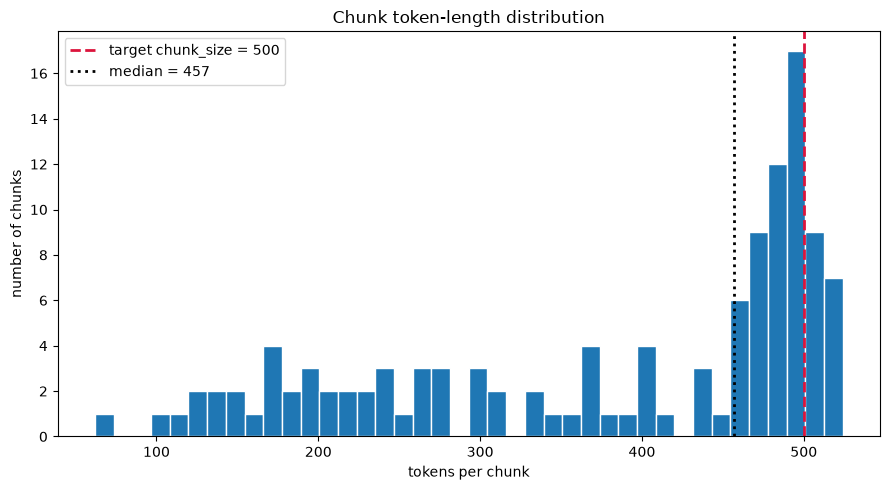

In [8]:
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(
    df["token_count"],
    bins=40,
    edgecolor="white"
)
ax.axvline(
    TARGET_CHUNK_SIZE,
    color="crimson",
    ls="--",
    lw=2,
    label=f"target chunk_size = {TARGET_CHUNK_SIZE}"
)
ax.axvline(
    df["token_count"].median(),
    color="black",
    ls=":",
    lw=2,
    label=f"median = {df['token_count'].median():.0f}"
)
ax.set(
    xlabel="tokens per chunk",
    ylabel="number of chunks",
    title="Chunk token-length distribution"
)

ax.legend()
fig.tight_layout()

plt.show()

## 5. Size flags

In [9]:
# Chunks below a useful size, and any exceeding the model context
too_small = df[df["token_count"] < MIN_USEFUL_TOKENS]
too_large = df[df["token_count"] > MODEL_CTX]

print(f"chunks below {MIN_USEFUL_TOKENS} tokens : {len(too_small)}  ({len(too_small)/len(df):.0%})")
print(f"chunks above {MODEL_CTX} (ctx)  : {len(too_large)}   <- must be 0")

if len(too_small):
    display(too_small[["chunk_id","title","token_count"]].head(10))

chunks below 100 tokens : 1  (1%)
chunks above 8192 (ctx)  : 0   <- must be 0


,chunk_id,title,token_count
0,1__000,INTRODUÇÃO,62


## 6. Integrity & quality

In [10]:
# Empty / near-empty chunks
near_empty = df[df["char_count"] < NEAR_EMPTY_CHARS]
print(f"empty and/or near-empty (<{NEAR_EMPTY_CHARS} chars): {len(near_empty)}")
if len(near_empty):
    display(near_empty[["chunk_id","title","char_count"]])

# Duplicate chunk ids (must be unique)
print("\nduplicate chunk_ids:", int(df["chunk_id"].duplicated().sum()))

empty and/or near-empty (<30 chars): 0

duplicate chunk_ids: 0


In [11]:
# Exact duplicate chunk text (beyond the intended overlap)
exact_dups = df["raw_text"].duplicated(keep=False)
print("exact duplicate chunk texts:", int(exact_dups.sum()))
if exact_dups.any():
    display(df.loc[exact_dups, ["chunk_id","title","token_count"]])

exact duplicate chunk texts: 0


In [12]:
# Noise ratios — stray whitespace / non-letter density
def noise_ratio(t):
    if not t: return 0.0
    non_alnum = sum(1 for c in t if not (c.isalnum() or c.isspace()))
    return round(non_alnum / len(t), 3)

df["noise_ratio"] = df["raw_text"].map(noise_ratio)
print("noise_ratio (punctuation/symbols share) — high values worth a look:")
display(df.sort_values("noise_ratio", ascending=False)
          [["chunk_id","title","noise_ratio","token_count"]].head(5))

noise_ratio (punctuation/symbols share) — high values worth a look:


,chunk_id,title,noise_ratio,token_count
18,2.3__001,Simulação,0.062,232
80,5.4.2__003,Modelação da Equação de NIOSH 91,0.057,483
47,5__002,DESENVOLVIMENTO E MODELAÇÃO DAS OPERAÇÕES DE LOJA,0.052,220
31,3.1__000,MC Sonae,0.049,408
77,5.4.2__000,Modelação da Equação de NIOSH 91,0.048,516


## 7. Structure & coverage

level distribution: {'subsection': 60, 'section': 47, 'chapter': 12}

chunks per chapter:
chapter_title
DESENVOLVIMENTO E MODELAÇÃO DAS OPERAÇÕES DE LOJA                                41
INTERPRETAÇÃO E DISCUSSÃO DOS RESULTADOS OBTIDOS E PROPOSTAS DE MELHORIA         29
ENQUADRAMENTO TEÓRICO                                                            24
ENQUADRAMENTO DO PROJETO                                                         11
INTRODUÇÃO                                                                        6
CONCLUSÃO                                                                         4
DESCRIÇÃO ANALÍTICA DO PROCESSO ATUAL E PARAMETRIZAÇÃO DO MODELO DE SIMULAÇÃO     4
dtype: int64


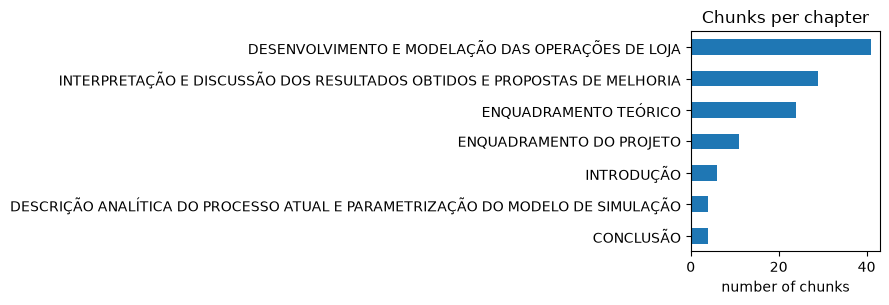

In [13]:
print("level distribution:", df["level"].value_counts().to_dict())

# Chunks per chapter — does one chapter dominate the index?
per_ch = (df.groupby("chapter_title").size()
          .sort_values(ascending=False))
print("\nchunks per chapter:")
print(per_ch)

fig, ax = plt.subplots(figsize=(9, max(3, 0.45*len(per_ch))))
per_ch.sort_values().plot.barh(ax=ax)
ax.set(
    xlabel="number of chunks",
    ylabel="",
    title="Chunks per chapter"
)

fig.tight_layout()

plt.show()

In [14]:
# Chunks per section — how much did sections split?
per_sec = df.groupby("number").size()
print("chunks per section — mean %.1f, max %d" % (per_sec.mean(), per_sec.max()))
print("\nmost-split sections:")
display(per_sec.sort_values(ascending=False).head(5)
        .rename("n_chunks").reset_index()
        .merge(df[["number","title"]].drop_duplicates(), on="number"))

chunks per section — mean 1.9, max 8

most-split sections:


,number,n_chunks,title
0,5.4.2,8,Modelação da Equação de NIOSH 91
1,5.1,7,Modelação das atividades de despicking e manus...
2,5.4.1,7,Modelação do Guia de Mital
3,5.2,7,Modelação das atividades de transporte e repos...
4,6.4,4,Análise Crítica


## 8. Conservation

Every section with real content should appear in the chunks. The ones missing
should be **only** the tiny intros filtered out by `min_tokens` — a long section
here is a silent-drop bug.

In [15]:
chunked = set(df["number"])
dropped = [s for s in sections if s.get("number") not in chunked]

print(f"{len(dropped)} sections produced no chunks:")
for s in dropped:
    print(f"  {str(s.get('number')):>6}  {str(s.get('level')):10}  "
          f"{len(s['text'].split()):4d} words  {s.get('title')}")
print("\n^ all should be short/navigational.")

0 sections produced no chunks:

^ all should be short/navigational.


## 9. Save machine-readable summary

In [17]:
summary = {
    "tokenizer": EMBEDDING_MODEL,
    "target_chunk_size": TARGET_CHUNK_SIZE,
    "n_chunks": int(len(df)),
    "token_stats": {k: float(v) for k,v in
                    df["token_count"].describe(percentiles=[.5,.95]).round(1).items()},
    "pct_below_min_useful": round(len(too_small)/len(df), 3),
    "n_above_context": int(len(too_large)),
    "duplicate_chunk_texts": int(df["raw_text"].duplicated().sum()),
    "chunks_per_section_mean": round(float(per_sec.mean()), 1),
    "levels": df["level"].value_counts().to_dict(),
    "sections_dropped": len(dropped),
}
out = Path("chunk_profile_summary.json")
out.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(summary, ensure_ascii=False, indent=2))
print("\nsaved ->", out)

{
  "tokenizer": "BAAI/bge-m3",
  "target_chunk_size": 500,
  "n_chunks": 119,
  "token_stats": {
    "count": 119.0,
    "mean": 379.8,
    "std": 133.4,
    "min": 62.0,
    "50%": 457.0,
    "95%": 515.0,
    "max": 524.0
  },
  "pct_below_min_useful": 0.008,
  "n_above_context": 0,
  "duplicate_chunk_texts": 0,
  "chunks_per_section_mean": 1.9,
  "levels": {
    "subsection": 60,
    "section": 47,
    "chapter": 12
  },
  "sections_dropped": 0
}

saved -> chunk_profile_summary.json
